In [2]:
import pathlib
import subprocess
import h5py
import numpy as np
import matplotlib.pyplot as plt
import re
import glob
import h5py
import matplotlib.animation as animation

import scipy.special as spl
import scipy.integrate
import mpmath as mpm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
import matplotlib.colors as mcolors
import matplotlib.cm as cm

fontsize_title = 22
fontsize_axis = 18
fontsize_tick = 18
fontsize_legend = 16
fontsize_cbar = 18

plt.rcParams.update({
    "font.size": fontsize_tick,
    "axes.titlesize": fontsize_title,
    "axes.labelsize": fontsize_axis,
    "xtick.labelsize": fontsize_tick,
    "ytick.labelsize": fontsize_tick,
    "legend.fontsize": fontsize_legend,
    "figure.titlesize": fontsize_title,
})

In [3]:
import os

os.getcwd()

'/net/fs06/d0/dabdulah/GFD_PROJECT/crust_convection/mantle2D_surefireWC1'

In [4]:
def make_2D_three_panel_animation(
    snapshot_dir="snapshots",
    file_prefix="snapshots_s",
    output_name="three_panel_T_C_w.gif",

    tasks=("T", "C", "w"),
    titles=("T", "C", "w"),

    fps=4,
    dpi=150,
    figsize=(15, 4.5),

    cmaps=("RdBu_r", None, "RdBu_r"),
    vmins=(None, None, None),
    vmaxs=(None, None, None),
    scale_from_last_half=True,

    nframes=None,        # desired number of frames; None uses all available frames
    frame_cutoff=None,   # old option; kept for compatibility
):
    """
    Makes a 3-panel 2D animation for x-z fields.

    Assumes each task has shape:
        (time, x, z)

    Panels:
        left   = tasks[0]
        middle = tasks[1]
        right  = tasks[2]

    Each panel has x,z axes and its own colorbar.

    nframes:
        If None, use all frames.
        If smaller than available frames, subsample evenly.
        If larger than available frames, use all frames.
    """

    import os
    import h5py
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.animation as animation
    import matplotlib.cm as cm
    import matplotlib.colors as mcolors

    def get_coord(dset, dim_index):
        keys = list(dset.dims[dim_index].keys())
        if len(keys) == 0:
            raise ValueError(f"No coordinate scale found for dimension {dim_index}")
        return np.asarray(dset.dims[dim_index][keys[0]])

    def find_snapshot_files(snapshot_dir="snapshots", file_prefix="snapshots_s"):
        files = []
        i = 1
        while True:
            fname = os.path.join(snapshot_dir, f"{file_prefix}{i}.h5")
            if os.path.exists(fname):
                files.append(fname)
                i += 1
            else:
                break

        if len(files) == 0:
            raise FileNotFoundError(f"No files found like {snapshot_dir}/{file_prefix}X.h5")

        return files

    # ----------------------------
    # Colormaps
    # ----------------------------
    cmap_list = []

    for task, cmap in zip(tasks, cmaps):
        if cmap is None and task == "C":
            cmap_obj = mcolors.LinearSegmentedColormap.from_list(
                "brown_to_red",
                [
                    (0.00, "black"),
                    (0.25, "saddlebrown"),
                    (1.00, "lightcoral"),
                ]
            )
        elif cmap is None:
            cmap_obj = cm.get_cmap("RdBu_r")
        else:
            cmap_obj = cm.get_cmap(cmap)

        cmap_list.append(cmap_obj)

    # ----------------------------
    # Find files and collect frames
    # ----------------------------
    files = find_snapshot_files(snapshot_dir, file_prefix)
    print(f"Found {len(files)} snapshot files.")

    frames = []

    for fname in files:
        print(f"Scanning {fname}")
        with h5py.File(fname, mode="r") as file:
            dset = file["tasks"][tasks[0]]
            t = np.asarray(dset.dims[0]["sim_time"])
            nt = dset.shape[0]

            for it in range(nt):
                frames.append((fname, it, t[it]))

    frames = sorted(frames, key=lambda item: item[2])

    # ----------------------------
    # Subsample frames if requested
    # ----------------------------
    if nframes is not None:
        nframes = int(nframes)

        if nframes <= 0:
            raise ValueError("nframes must be positive")

        if nframes < len(frames):
            inds = np.linspace(0, len(frames) - 1, nframes).astype(int)
            frames = [frames[i] for i in inds]
            print(f"Using {len(frames)} evenly subsampled frames.")
        else:
            print(f"Requested nframes={nframes}, but only {len(frames)} frames exist. Using all frames.")

    # ----------------------------
    # Coordinates
    # ----------------------------
    first_fname, first_it, first_time = frames[0]

    with h5py.File(first_fname, mode="r") as file:
        dset = file["tasks"][tasks[0]]
        x = get_coord(dset, 1)
        z = get_coord(dset, 2)

    x0, x1 = x.min(), x.max()
    z0, z1 = z.min(), z.max()

    X, Z = np.meshgrid(x, z, indexing="ij")

    print("x min/max:", x0, x1)
    print("z min/max:", z0, z1)

    # ----------------------------
    # Color limits
    # ----------------------------
    def scan_task_limits(task, user_vmin, user_vmax):
        if user_vmin is not None and user_vmax is not None:
            return user_vmin, user_vmax

        vals = []
        scan_frames = frames[len(frames)//2:] if scale_from_last_half else frames

        print(f"Scanning color limits for {task}...")

        for fname, it, sim_time in scan_frames:
            with h5py.File(fname, mode="r") as file:
                A = np.asarray(file["tasks"][task][it, :, :])
                vals.append(np.nanmin(A))
                vals.append(np.nanmax(A))

        data_min = np.nanmin(vals)
        data_max = np.nanmax(vals)

        if user_vmin is None:
            user_vmin = data_min
        if user_vmax is None:
            user_vmax = data_max

        return user_vmin, user_vmax

    norms = []
    for task, vmin, vmax in zip(tasks, vmins, vmaxs):
        vmin, vmax = scan_task_limits(task, vmin, vmax)

        if task == "w":
            vmax_abs = max(abs(vmin), abs(vmax))
            vmin = -vmax_abs
            vmax = vmax_abs

        print(f"{task} vmin/vmax:", vmin, vmax)
        norms.append(mcolors.Normalize(vmin=vmin, vmax=vmax))

    # ----------------------------
    # Figure setup
    # ----------------------------
    fig, axes = plt.subplots(1, 3, figsize=figsize)

    fig.subplots_adjust(
        left=0.06,
        right=0.92,
        bottom=0.12,
        top=0.86,
        wspace=0.35,
    )

    ims = []

    with h5py.File(first_fname, mode="r") as file:
        for ax, task, title, cmap, norm in zip(axes, tasks, titles, cmap_list, norms):
            A = np.asarray(file["tasks"][task][first_it, :, :])

            im = ax.pcolormesh(
                X, Z, A,
                shading="auto",
                cmap=cmap,
                norm=norm,
            )

            ax.set_title(title)
            ax.set_xlabel("x")
            ax.set_ylabel("z")
            ax.set_xlim(x0, x1)
            ax.set_ylim(z0, z1)

            fig.colorbar(im, ax=ax)

            ims.append(im)

    fig.suptitle(f"time = {first_time:.2f}")

    # ----------------------------
    # Animation update
    # ----------------------------
    def update(frame_number):
        fname, it, sim_time = frames[frame_number]

        with h5py.File(fname, mode="r") as file:
            for im, task in zip(ims, tasks):
                A = np.asarray(file["tasks"][task][it, :, :])
                im.set_array(A.ravel())

        fig.suptitle(f"time = {sim_time:.2f}")

        print(
            f"Frame {frame_number + 1}/{frame_cutoff if frame_cutoff is not None else len(frames)}: "
            f"{fname}, index {it}, time {sim_time:.2f}"
        )

        return ims

    if frame_cutoff is None:
        frame_cutoff = len(frames)
    else:
        frame_cutoff = min(frame_cutoff, len(frames))

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=frame_cutoff,
        interval=1000 / fps,
        blit=False,
    )

    ani.save(output_name, writer="pillow", fps=fps, dpi=dpi)
    print(f"Saved animation to {output_name}")

<ipython-input-3-c65f71a18b67>:88: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = cm.get_cmap(cmap)


Found 5 snapshot files.
Scanning snapshots/snapshots_s1.h5
Scanning snapshots/snapshots_s2.h5
Scanning snapshots/snapshots_s3.h5
Scanning snapshots/snapshots_s4.h5
Scanning snapshots/snapshots_s5.h5
Using 150 evenly subsampled frames.
x min/max: 0.0 3.9921874999999996
z min/max: 3.7649080427748505e-05 0.9999623509195723
Scanning color limits for T...
T vmin/vmax: 0.00010389483502536972 1.3898899754621314
C vmin/vmax: 0 1
Scanning color limits for w...
w vmin/vmax: -40.66702085932985 40.66702085932985
Frame 1/150: snapshots/snapshots_s1.h5, index 0, time 0.00
Frame 1/150: snapshots/snapshots_s1.h5, index 0, time 0.00
Frame 2/150: snapshots/snapshots_s1.h5, index 1, time 0.05
Frame 3/150: snapshots/snapshots_s1.h5, index 2, time 0.06
Frame 4/150: snapshots/snapshots_s1.h5, index 4, time 0.06
Frame 5/150: snapshots/snapshots_s1.h5, index 5, time 0.06
Frame 6/150: snapshots/snapshots_s1.h5, index 7, time 0.07
Frame 7/150: snapshots/snapshots_s1.h5, index 8, time 0.07
Frame 8/150: snapshots

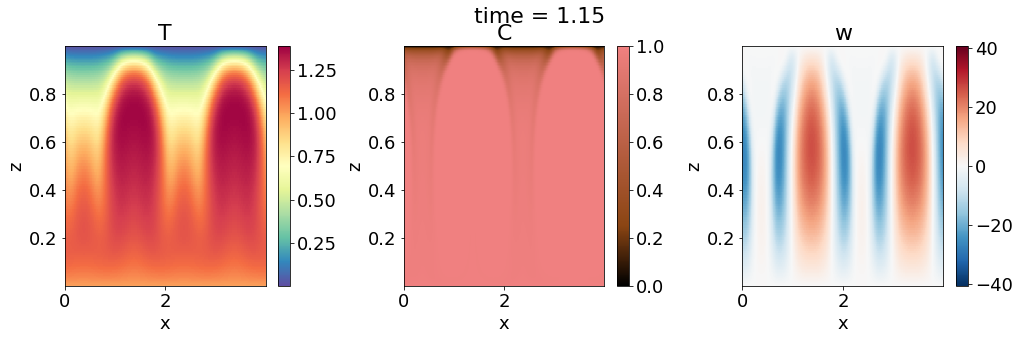

In [5]:
make_2D_three_panel_animation(
    snapshot_dir="snapshots",
    file_prefix="snapshots_s",
    output_name="WC1_T_C_w.gif",

    tasks=("T", "C", "w"),
    titles=("T", "C", "w"),

    cmaps=("Spectral_r", None, "RdBu_r"),
    vmins=(None, 0, None),
    vmaxs=(None, 1, None),

    fps=4,
    dpi=150,
    figsize=(15, 4.5),

    nframes=150,
    frame_cutoff=None,
)

<ipython-input-3-c65f71a18b67>:88: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = cm.get_cmap(cmap)


Found 36 snapshot files.
Scanning snapshots/snapshots_s1.h5
Scanning snapshots/snapshots_s2.h5
Scanning snapshots/snapshots_s3.h5
Scanning snapshots/snapshots_s4.h5
Scanning snapshots/snapshots_s5.h5
Scanning snapshots/snapshots_s6.h5
Scanning snapshots/snapshots_s7.h5
Scanning snapshots/snapshots_s8.h5
Scanning snapshots/snapshots_s9.h5
Scanning snapshots/snapshots_s10.h5
Scanning snapshots/snapshots_s11.h5
Scanning snapshots/snapshots_s12.h5
Scanning snapshots/snapshots_s13.h5
Scanning snapshots/snapshots_s14.h5
Scanning snapshots/snapshots_s15.h5
Scanning snapshots/snapshots_s16.h5
Scanning snapshots/snapshots_s17.h5
Scanning snapshots/snapshots_s18.h5
Scanning snapshots/snapshots_s19.h5
Scanning snapshots/snapshots_s20.h5
Scanning snapshots/snapshots_s21.h5
Scanning snapshots/snapshots_s22.h5
Scanning snapshots/snapshots_s23.h5
Scanning snapshots/snapshots_s24.h5
Scanning snapshots/snapshots_s25.h5
Scanning snapshots/snapshots_s26.h5
Scanning snapshots/snapshots_s27.h5
Scanning sna

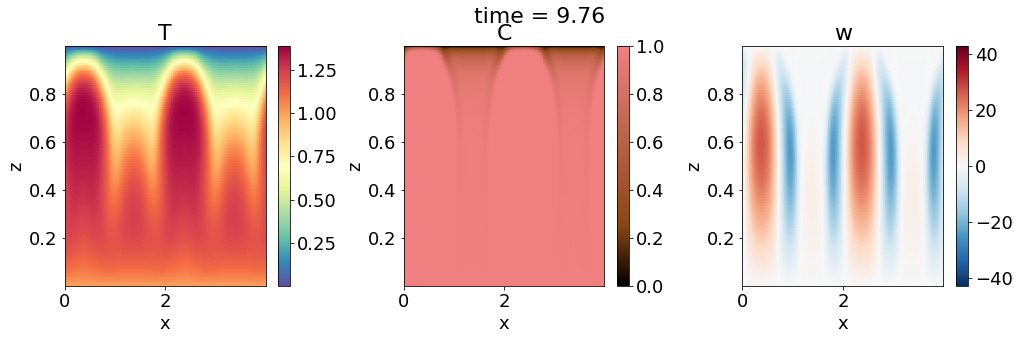

In [7]:
make_2D_three_panel_animation(
    snapshot_dir="snapshots",
    file_prefix="snapshots_s",
    output_name="WC1_T_C_w.gif",

    tasks=("T", "C", "w"),
    titles=("T", "C", "w"),

    cmaps=("Spectral_r", None, "RdBu_r"),
    vmins=(None, 0, None),
    vmaxs=(None, 1, None),

    fps=4,
    dpi=150,
    figsize=(15, 4.5),

    nframes=150,
    frame_cutoff=None,
)

<ipython-input-4-c65f71a18b67>:88: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = cm.get_cmap(cmap)


Found 14 snapshot files.
Scanning snapshots_seeded/snapshots_seeded_s1.h5
Scanning snapshots_seeded/snapshots_seeded_s2.h5
Scanning snapshots_seeded/snapshots_seeded_s3.h5
Scanning snapshots_seeded/snapshots_seeded_s4.h5
Scanning snapshots_seeded/snapshots_seeded_s5.h5
Scanning snapshots_seeded/snapshots_seeded_s6.h5
Scanning snapshots_seeded/snapshots_seeded_s7.h5
Scanning snapshots_seeded/snapshots_seeded_s8.h5
Scanning snapshots_seeded/snapshots_seeded_s9.h5
Scanning snapshots_seeded/snapshots_seeded_s10.h5
Scanning snapshots_seeded/snapshots_seeded_s11.h5
Scanning snapshots_seeded/snapshots_seeded_s12.h5
Scanning snapshots_seeded/snapshots_seeded_s13.h5
Scanning snapshots_seeded/snapshots_seeded_s14.h5
Using 150 evenly subsampled frames.
x min/max: 0.0 3.984375
z min/max: 0.00015059065189787502 0.9998494093481021
Scanning color limits for T...
T vmin/vmax: 0.0004164060351407386 1.3898122385971032
C vmin/vmax: 0 1
Scanning color limits for w...
w vmin/vmax: -42.16031517112642 42.160

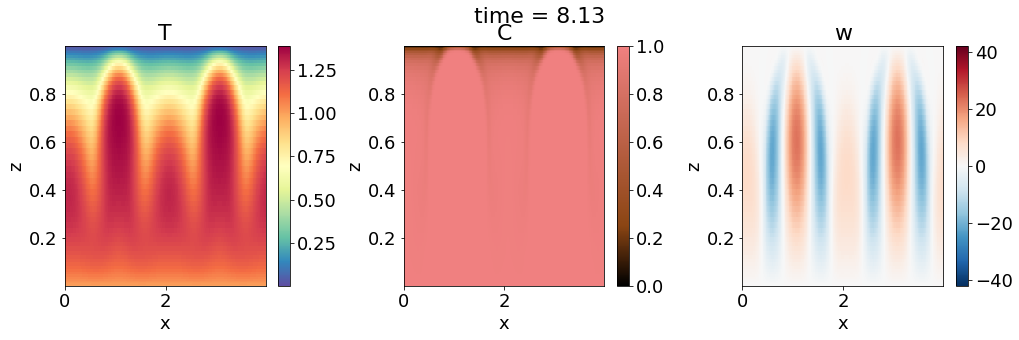

In [8]:
make_2D_three_panel_animation(
    snapshot_dir="snapshots_seeded",
    file_prefix="snapshots_seeded_s",
    output_name="seeded_T_C_w.gif",

    tasks=("T", "C", "w"),
    titles=("T", "C", "w"),

    cmaps=("Spectral_r", None, "RdBu_r"),
    vmins=(None, 0, None),
    vmaxs=(None, 1, None),

    fps=4,
    dpi=150,
    figsize=(15, 4.5),

    nframes=150,
    frame_cutoff=None,
)